In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16,preprocess_input,decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

In [ ]:
print("****Loading Pretrained Model***")
model = VGG16(weights='imagenet')
print("Model Loaded")

****Loading Pretrained Model***
553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Model Loaded


In [ ]:
#Function to load and classify image
def classify_image(img_path):
    if img_path.startswith('http'):
        response = requests.get(img_path)
        img = Image.open(BytesIO(response.content))
    else:
        img = image.load_img(img_path,target_size=(224,224))
    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Input Image")
    plt.show()
    #Preprocessing Image
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array,axis=0)
    img_array = preprocess_input(img_array)
    print("")
    #Make Predictions
    print("\nClassifying ...")
    predictions = model.predict(img_array)
    print("\nPrediction Complete")
    #decoded predictions
    decoded = decode_predictions(predictions,top=1)[0]
    #print( results)
    for i,(imagenet_id,label,score) in enumerate(decoded):
        print(f"{i+1}.{label} : {score*100:.2f}%")
    return decoded


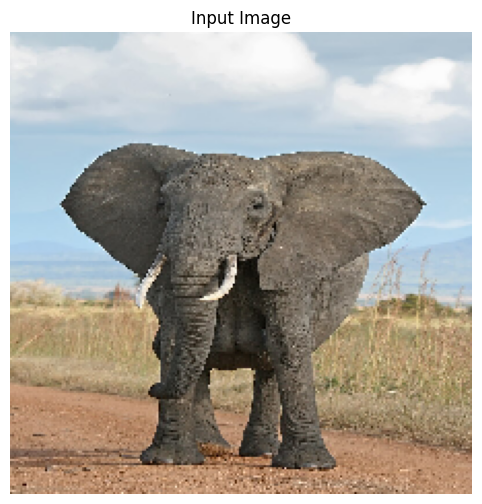



Classifying ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Prediction Complete
1.African_elephant : 88.39%


[('n02504458', 'African_elephant', np.float32(0.8838513))]

In [ ]:
classify_image("/content/Elephant.jpg")

In [ ]:
import keras
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

model = ResNet50(weights='imagenet')

img_path = '/content/europian.jpg'
img = keras.utils.load_img(img_path, target_size=(224, 224))
x = keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = model.predict(x)
# decode the results into a list of tuples (class, description, probability)
# (one such list for each sample in the batch)
print('Predicted:', decode_predictions(preds, top=3)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted: [('n01871265', 'tusker', np.float32(0.7220133)), ('n02504013', 'Indian_elephant', np.float32(0.23345792)), ('n02504458', 'African_elephant', np.float32(0.044435456))]


In [ ]:
#Function to load and classify image
def classify_image(img_path):
    if img_path.startswith('http'):
        response = requests.get(img_path)
        img = Image.open(BytesIO(response.content))
    else:
        img = image.load_img(img_path,target_size=(224,224))
    #plt.figure(figsize=(8,6))
    #plt.imshow(img)
    #plt.axis('off')
    #plt.title("Input Image")
    #plt.show()
    #Preprocessing Image
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array,axis=0)
    img_array = preprocess_input(img_array)
    #print("")
    #Make Predictions
    #print("\nClassifying ...")
    predictions = model.predict(img_array)
    #print("\nPrediction Complete")
    #decoded predictions
    decoded = decode_predictions(predictions,top=1)[0]
    #print( results)
    results = {label:float(score) for (_,label,score) in decoded}
    return results

In [ ]:
def classify_img(img):
  img = Image.fromarray(img.astype('uint8'),'RGB')
  img = img.resize((224,224))
  img_array = image.img_to_array(img)
  img_array = np.expand_dims(img_array,axis=0)
  img_array = preprocess_input(img_array)
  predictions = model.predict(img_array)
  decoded = decode_predictions(predictions,top=5)[0]
  results = {label:float(score) for (_,label,score) in decoded}
  return results

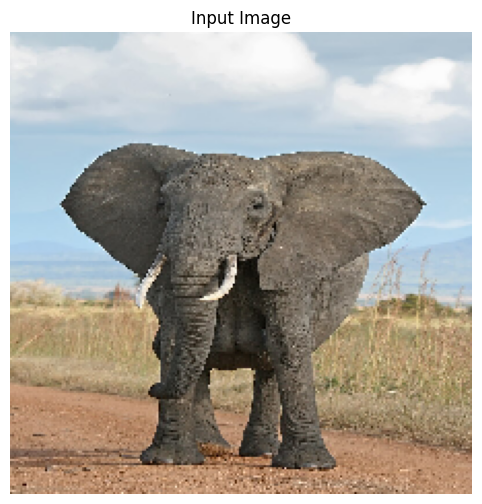



Classifying ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Prediction Complete
African_elephant : 83.17%


In [ ]:
results = classify_image('/content/Elephant.jpg')
for label, score in results.items():
    print(f"{label} : {score*100:.2f}%")

In [ ]:
def test_funct(img):
  results=classify_image(img)
  return results

In [ ]:
test_funct('/content/Elephant.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


{'African_elephant': 0.8317101001739502}

In [ ]:
import gradio as gr

In [ ]:
interface = gr.Interface(fn=test_funct,inputs= gr.Image(),outputs=gr.Label(num_top_classes=3))

In [ ]:
interface.launch(share = True,debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://87f9c0de1c5afa8f3b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1133, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://87f9c0de1c5afa8f3b.gradio.live
